![](img/banner.png)
%%HTML
<script src="require.js"></script>

## Add coordinates as spatial features to clustering

Image Segmentation, Add pixels's coordinates

**Mahmood Amintoosi, Fall 2025**

Computer Science Dept, Ferdowsi University of Mashhad

In [1]:
# Importing Necessary Libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from skimage import data
from skimage.color import rgb2gray
from skimage.transform import resize

In [4]:
coffee = data.coffee()
# coffee = data.cat()
coffee =  resize(coffee, (coffee.shape[0] // 2, coffee.shape[1] // 2),
                       anti_aliasing=True)
gray_coffee = rgb2gray(coffee)

X = coffee.reshape((-1,3))

K = 16
kmeans = KMeans(n_clusters=K)

# Clustering only pixels' intensities
kmeans.fit(X)
labels = kmeans.labels_
seg_img_kmeans = labels.reshape(gray_coffee.shape)

# Clustering intensities and coordinates

# create an array of x and y coordinates for each pixel
h, w = gray_coffee.shape
xx, yy = np.meshgrid(np.arange(w), np.arange(h))
coords = np.concatenate((xx.reshape(-1,1),yy.reshape(-1,1)),axis=1)
# coords = np.c_[xx.ravel(), yy.ravel()]

# append the coordinates to the grayscale values
X_xy = np.concatenate((X, coords), axis=1)
# X = np.c_[X, coords]

# Normalizing X
X_xy = X_xy / X_xy.max(axis = 0)

kmeans = KMeans(n_clusters=K)
kmeans.fit(X_xy)
labels_xy = kmeans.labels_
# cluster_centers = kmeans.cluster_centers_
seg_img_kmeans_xy = labels_xy.reshape(gray_coffee.shape)

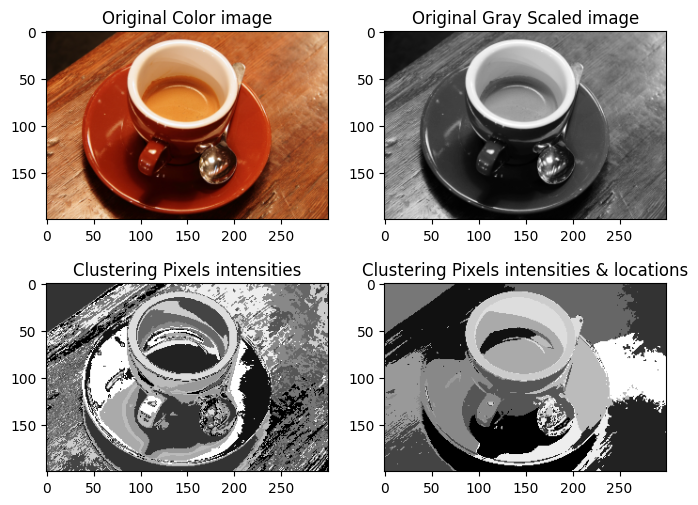

In [5]:
plt.figure(figsize=(8, 6))
plt.subplot(2,2,1)
plt.imshow(coffee)
plt.title('Original Color image')
plt.subplot(2,2,2)
plt.imshow(gray_coffee, cmap = 'gray')
plt.title('Original Gray Scaled image')
plt.subplot(2,2,3)
plt.imshow(seg_img_kmeans, cmap = 'gray')
plt.title('Clustering Pixels intensities')
plt.subplot(2,2,4)
plt.imshow(seg_img_kmeans_xy, cmap = 'gray')
plt.title('Clustering Pixels intensities & locations');


Reorder labels, base on the gray scale image

In [6]:
gray_pixels = gray_coffee.flatten()
mean_gray_pixels = np.zeros(K)
for k in range(K):
    mean_gray_pixels[k] = np.mean(gray_pixels[labels == k])

order = np.argsort(mean_gray_pixels)
# order, mean_gray_pixels, labels

In [7]:
new_labels = np.zeros_like(labels)
for k in range(K):
    new_labels[labels==k] = np.where(order == k)[0]

seg_img_kmeans = new_labels.reshape(gray_coffee.shape)
# labels[:5], new_labels[:5]

In [8]:
mean_gray_pixels = np.zeros(K)
for k in range(K):
    mean_gray_pixels[k] = np.mean(gray_pixels[labels_xy == k])

order = np.argsort(mean_gray_pixels)
new_labels_xy = np.zeros_like(labels_xy)
for k in range(K):
    new_labels_xy[labels_xy==k] = np.where(order == k)[0]
# new_labels    
seg_img_kmeans_xy = new_labels_xy.reshape(gray_coffee.shape)

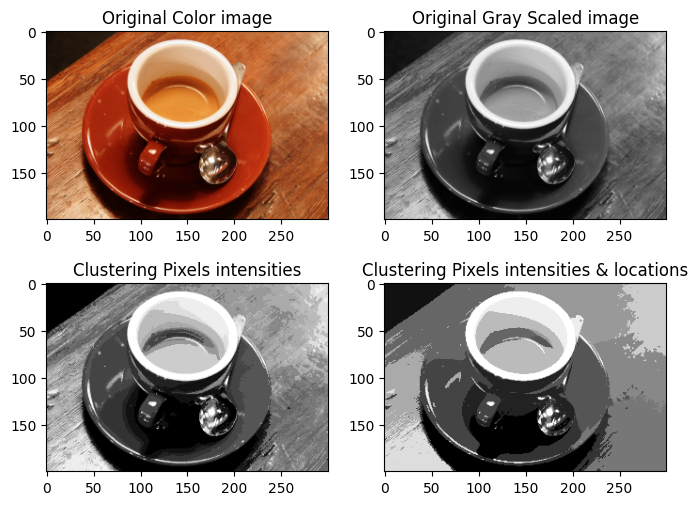

In [9]:
plt.figure(figsize=(8, 6))
plt.subplot(2,2,1)
plt.imshow(coffee, cmap = 'gray')
plt.title('Original Color image')
plt.subplot(2,2,2)
plt.imshow(gray_coffee, cmap = 'gray')
plt.title('Original Gray Scaled image')
plt.subplot(2,2,3)
plt.imshow(seg_img_kmeans, cmap = 'gray')
plt.title('Clustering Pixels intensities')
plt.subplot(2,2,4)
plt.imshow(seg_img_kmeans_xy, cmap = 'gray')
plt.title('Clustering Pixels intensities & locations');

In [4]:
# --- Cell 1: True Naive Bayes for Image Segmentation ---
def true_naive_bayes_segmentation(image, bg_params, fg_params):
    """
    True Naive Bayes segmentation using pre-defined parameters
    This assumes we already know the class distributions
    """
    pixels = image.flatten().astype(np.float64)
    
    # Extract parameters
    bg_mean, bg_std, bg_prior = bg_params
    fg_mean, fg_std, fg_prior = fg_params
    
    # Calculate posterior probabilities for each pixel
    posteriors_bg = np.zeros_like(pixels)
    posteriors_fg = np.zeros_like(pixels)
    
    for i, pixel in enumerate(pixels):
        # Likelihoods
        bg_likelihood = norm.pdf(pixel, bg_mean, bg_std)
        fg_likelihood = norm.pdf(pixel, fg_mean, fg_std)
        
        # Posteriors
        bg_posterior = bg_prior * bg_likelihood
        fg_posterior = fg_prior * fg_likelihood
        
        # Normalize
        total = bg_posterior + fg_posterior
        if total > 0:
            posteriors_bg[i] = bg_posterior / total
            posteriors_fg[i] = fg_posterior / total
    
    # Decision: assign to class with highest posterior
    segmentation = (posteriors_fg > posteriors_bg).astype(np.uint8) * 255
    segmentation = segmentation.reshape(image.shape)
    
    return segmentation, posteriors_bg, posteriors_fg

# --- Cell 2: GMM with EM (What we actually implemented) ---
def gmm_em_segmentation(image, max_iterations=100, tolerance=1e-6):
    """
    This is actually GMM with EM algorithm
    The previous implementation was this method
    """
    # This is exactly the same as our previous bayes_threshold_segmentation
    # but let's rename it correctly
    pixels = image.flatten().astype(np.float64)
    
    # Initialize parameters
    threshold = np.mean(pixels)
    prev_threshold = 0
    
    print("GMM-EM Segmentation Algorithm")
    print("=" * 40)
    
    for iteration in range(max_iterations):
        if abs(threshold - prev_threshold) < tolerance:
            break
            
        prev_threshold = threshold
        
        # E-step: Estimate posterior probabilities
        bg_pixels = pixels[pixels <= threshold]
        fg_pixels = pixels[pixels > threshold]
        
        # M-step: Update parameters
        bg_mean = np.mean(bg_pixels) if len(bg_pixels) > 0 else 0
        bg_std = np.std(bg_pixels) if len(bg_pixels) > 0 else 1
        bg_prior = len(bg_pixels) / len(pixels)
        
        fg_mean = np.mean(fg_pixels) if len(fg_pixels) > 0 else 255
        fg_std = np.std(fg_pixels) if len(fg_pixels) > 0 else 1
        fg_prior = len(fg_pixels) / len(pixels)
        
        # Find new threshold (where posteriors are equal)
        new_threshold = find_optimal_threshold(bg_mean, bg_std, bg_prior, 
                                             fg_mean, fg_std, fg_prior)
        threshold = new_threshold
    
    return threshold, (bg_mean, bg_std, bg_prior), (fg_mean, fg_std, fg_prior)

def find_optimal_threshold(bg_mean, bg_std, bg_prior, fg_mean, fg_std, fg_prior):
    """Find threshold where posterior probabilities are equal"""
    optimal_thresh = 0
    min_diff = float('inf')
    
    for intensity in range(256):
        bg_likelihood = norm.pdf(intensity, bg_mean, bg_std)
        fg_likelihood = norm.pdf(intensity, fg_mean, fg_std)
        
        bg_posterior = bg_prior * bg_likelihood
        fg_posterior = fg_prior * fg_likelihood
        
        total = bg_posterior + fg_posterior
        if total > 0:
            bg_posterior /= total
            fg_posterior /= total
        
        diff = abs(bg_posterior - fg_posterior)
        if diff < min_diff:
            min_diff = diff
            optimal_thresh = intensity
    
    return optimal_thresh

COMPARISON: Naive Bayes vs GMM-EM

1. GMM-EM Method (Parameters learned from data)
GMM-EM Segmentation Algorithm

2. True Naive Bayes (Using pre-defined parameters)

3. Naive Bayes with GMM-learned parameters


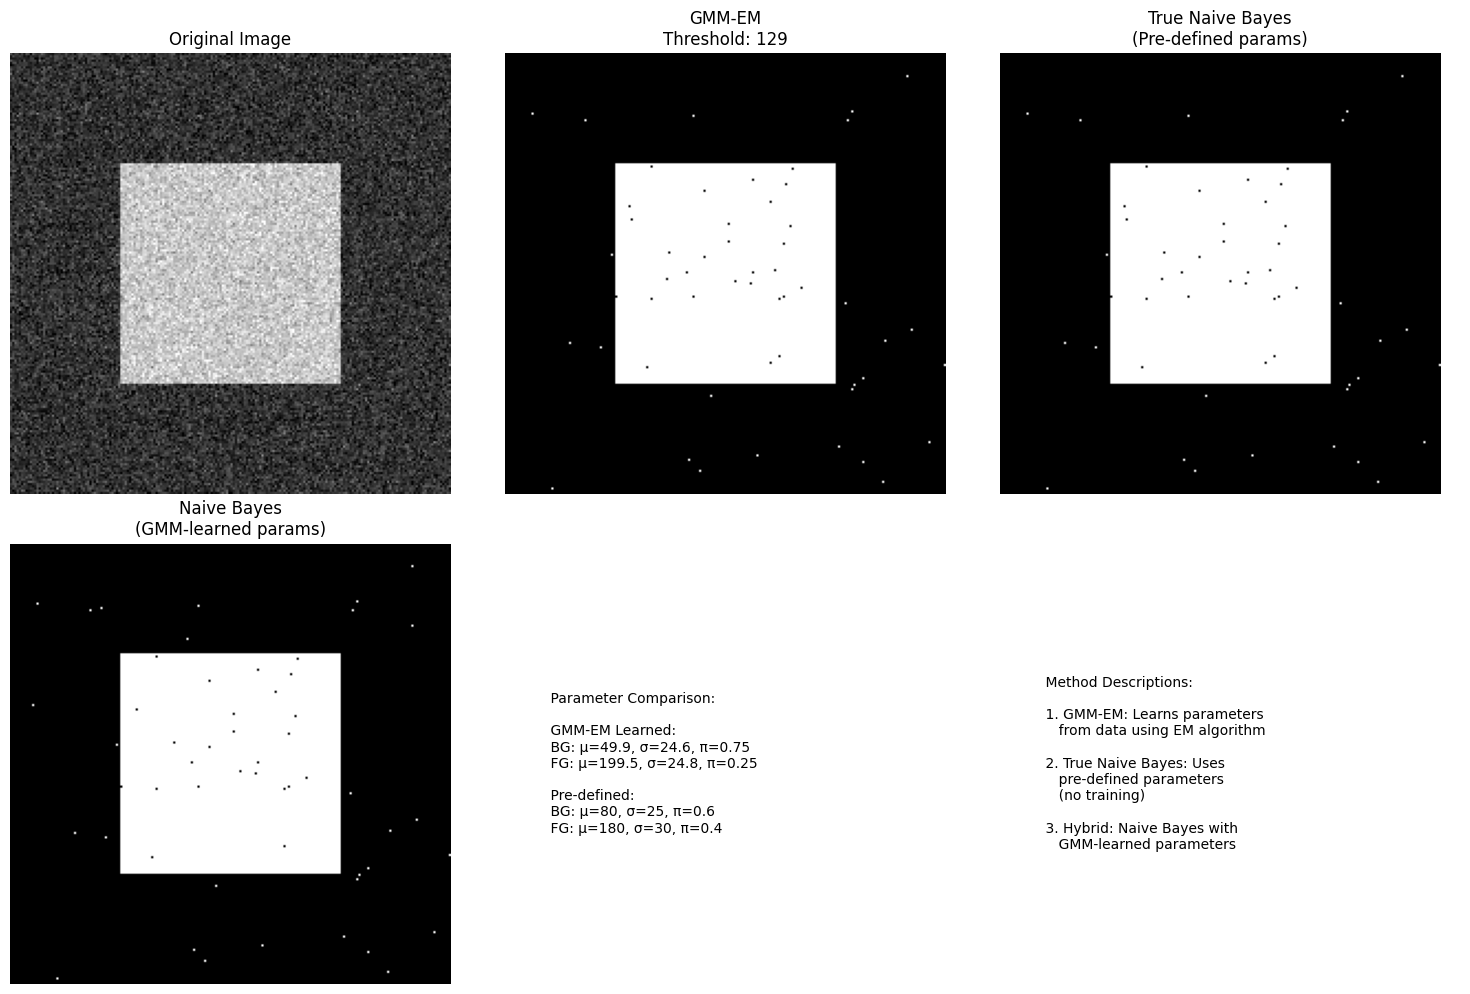


SUMMARY
GMM-EM: Learns parameters from data (what we initially implemented)
True Naive Bayes: Uses fixed, pre-defined parameters
Both use Bayes' theorem for inference, but differ in parameter estimation


In [5]:
# --- Cell 3: Comparison of Both Methods ---
def compare_naive_bayes_vs_gmm(image):
    """
    Compare True Naive Bayes vs GMM-EM approaches
    """
    
    print("COMPARISON: Naive Bayes vs GMM-EM")
    print("=" * 50)
    
    # Method 1: GMM-EM (Learn parameters from data)
    print("\n1. GMM-EM Method (Parameters learned from data)")
    gmm_threshold, gmm_bg_params, gmm_fg_params = gmm_em_segmentation(image)
    
    # Method 2: True Naive Bayes (Use pre-defined parameters)
    print("\n2. True Naive Bayes (Using pre-defined parameters)")
    # Let's assume we know the parameters from domain knowledge
    known_bg_params = (80, 25, 0.6)  # (mean, std, prior)
    known_fg_params = (180, 30, 0.4) # (mean, std, prior)
    
    nb_segmentation, nb_posteriors_bg, nb_posteriors_fg = true_naive_bayes_segmentation(
        image, known_bg_params, known_fg_params)
    
    # Method 3: Naive Bayes with GMM-learned parameters
    print("\n3. Naive Bayes with GMM-learned parameters")
    nb_gmm_segmentation, _, _ = true_naive_bayes_segmentation(
        image, gmm_bg_params, gmm_fg_params)
    
    # Display results
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Original image
    axes[0, 0].imshow(image, cmap='gray')
    axes[0, 0].set_title('Original Image')
    axes[0, 0].axis('off')
    
    # GMM-EM result
    gmm_binary = (image > gmm_threshold).astype(np.uint8) * 255
    axes[0, 1].imshow(gmm_binary, cmap='gray')
    axes[0, 1].set_title(f'GMM-EM\nThreshold: {gmm_threshold}')
    axes[0, 1].axis('off')
    
    # True Naive Bayes with known parameters
    axes[0, 2].imshow(nb_segmentation, cmap='gray')
    axes[0, 2].set_title('True Naive Bayes\n(Pre-defined params)')
    axes[0, 2].axis('off')
    
    # Naive Bayes with GMM parameters
    axes[1, 0].imshow(nb_gmm_segmentation, cmap='gray')
    axes[1, 0].set_title('Naive Bayes\n(GMM-learned params)')
    axes[1, 0].axis('off')
    
    # Parameter comparison
    axes[1, 1].axis('off')
    param_text = f"""
    Parameter Comparison:
    
    GMM-EM Learned:
    BG: μ={gmm_bg_params[0]:.1f}, σ={gmm_bg_params[1]:.1f}, π={gmm_bg_params[2]:.2f}
    FG: μ={gmm_fg_params[0]:.1f}, σ={gmm_fg_params[1]:.1f}, π={gmm_fg_params[2]:.2f}
    
    Pre-defined:
    BG: μ={known_bg_params[0]}, σ={known_bg_params[1]}, π={known_bg_params[2]}
    FG: μ={known_fg_params[0]}, σ={known_fg_params[1]}, π={known_fg_params[2]}
    """
    axes[1, 1].text(0.1, 0.5, param_text, transform=axes[1, 1].transAxes, 
                   fontsize=10, verticalalignment='center')
    
    # Method descriptions
    axes[1, 2].axis('off')
    desc_text = """
    Method Descriptions:
    
    1. GMM-EM: Learns parameters 
       from data using EM algorithm
    
    2. True Naive Bayes: Uses 
       pre-defined parameters
       (no training)
    
    3. Hybrid: Naive Bayes with
       GMM-learned parameters
    """
    axes[1, 2].text(0.1, 0.5, desc_text, transform=axes[1, 2].transAxes,
                   fontsize=10, verticalalignment='center')
    
    plt.tight_layout()
    plt.show()
    
    return gmm_threshold, nb_segmentation, nb_gmm_segmentation

# --- Cell 4: Test the Corrected Methods ---
def test_corrected_methods():
    """Test both corrected methods"""
    
    # Create test image
    test_image = create_test_image()
    
    # Compare methods
    gmm_thresh, nb_result, hybrid_result = compare_naive_bayes_vs_gmm(test_image)
    
    print("\n" + "="*50)
    print("SUMMARY")
    print("="*50)
    print("GMM-EM: Learns parameters from data (what we initially implemented)")
    print("True Naive Bayes: Uses fixed, pre-defined parameters")
    print("Both use Bayes' theorem for inference, but differ in parameter estimation")

if __name__ == "__main__":
    test_corrected_methods()

# Educational Section: Image Segmentation using Naive Bayes Method

## Introduction

In this section, we will explore the Naive Bayes method for image segmentation. This method is based on Bayes' theorem and is particularly suitable for two-class images such as medical images or document images.

## Theory of Bayes Method for Image Segmentation

### Problem Formulation

We assume our image has two classes:
- Class 0 (Background)
- Class 1 (Foreground)

For each pixel with intensity value $x$, we want to calculate its probability of belonging to each class.

### Bayes' Theorem

According to Bayes' theorem, the probability of a pixel belonging to class $C_k$ is:

$$
P(C_k | x) = \frac{P(x | C_k) \cdot P(C_k)}{P(x)}
$$

where:
- $P(C_k | x)$: Posterior probability
- $P(x | C_k)$: Likelihood
- $P(C_k)$: Prior probability
- $P(x)$: Evidence

### Model Assumptions

1. **Gaussian Distribution**: We assume pixel intensities in each class follow a Gaussian distribution:

$$
P(x | C_k) = \frac{1}{\sqrt{2\pi\sigma_k^2}} \exp\left(-\frac{(x - \mu_k)^2}{2\sigma_k^2}\right)
$$

2. **Independence**: Pixels are considered independent (Naive Bayes assumption)

### Decision Rule

Pixel $x$ is assigned to the class with the highest posterior probability:

$$
\hat{C} = \arg\max_{k} P(C_k | x)
$$

## Implementation from Scratch

Here's the Python code implementing this method from scratch:

Testing Bayes Image Segmentation Method

Test 1: Simple test image
Starting Bayes segmentation algorithm...
Iteration 1:
  Threshold: 87.00
  Background - Mean: 48.16, Std: 18.51, Prior: 0.729
  Foreground - Mean: 191.64, Std: 33.85, Prior: 0.271
Iteration 2:
  Threshold: 106.00
  Background - Mean: 49.35, Std: 19.68, Prior: 0.749
  Foreground - Mean: 199.16, Std: 21.02, Prior: 0.251
Iteration 3:
  Threshold: 125.00
  Background - Mean: 49.46, Std: 19.85, Prior: 0.750
  Foreground - Mean: 199.64, Std: 20.03, Prior: 0.250
Iteration 4:
  Threshold: 127.00
  Background - Mean: 49.47, Std: 19.85, Prior: 0.750
  Foreground - Mean: 199.65, Std: 20.02, Prior: 0.250
Algorithm converged at iteration 4
Final threshold: 127


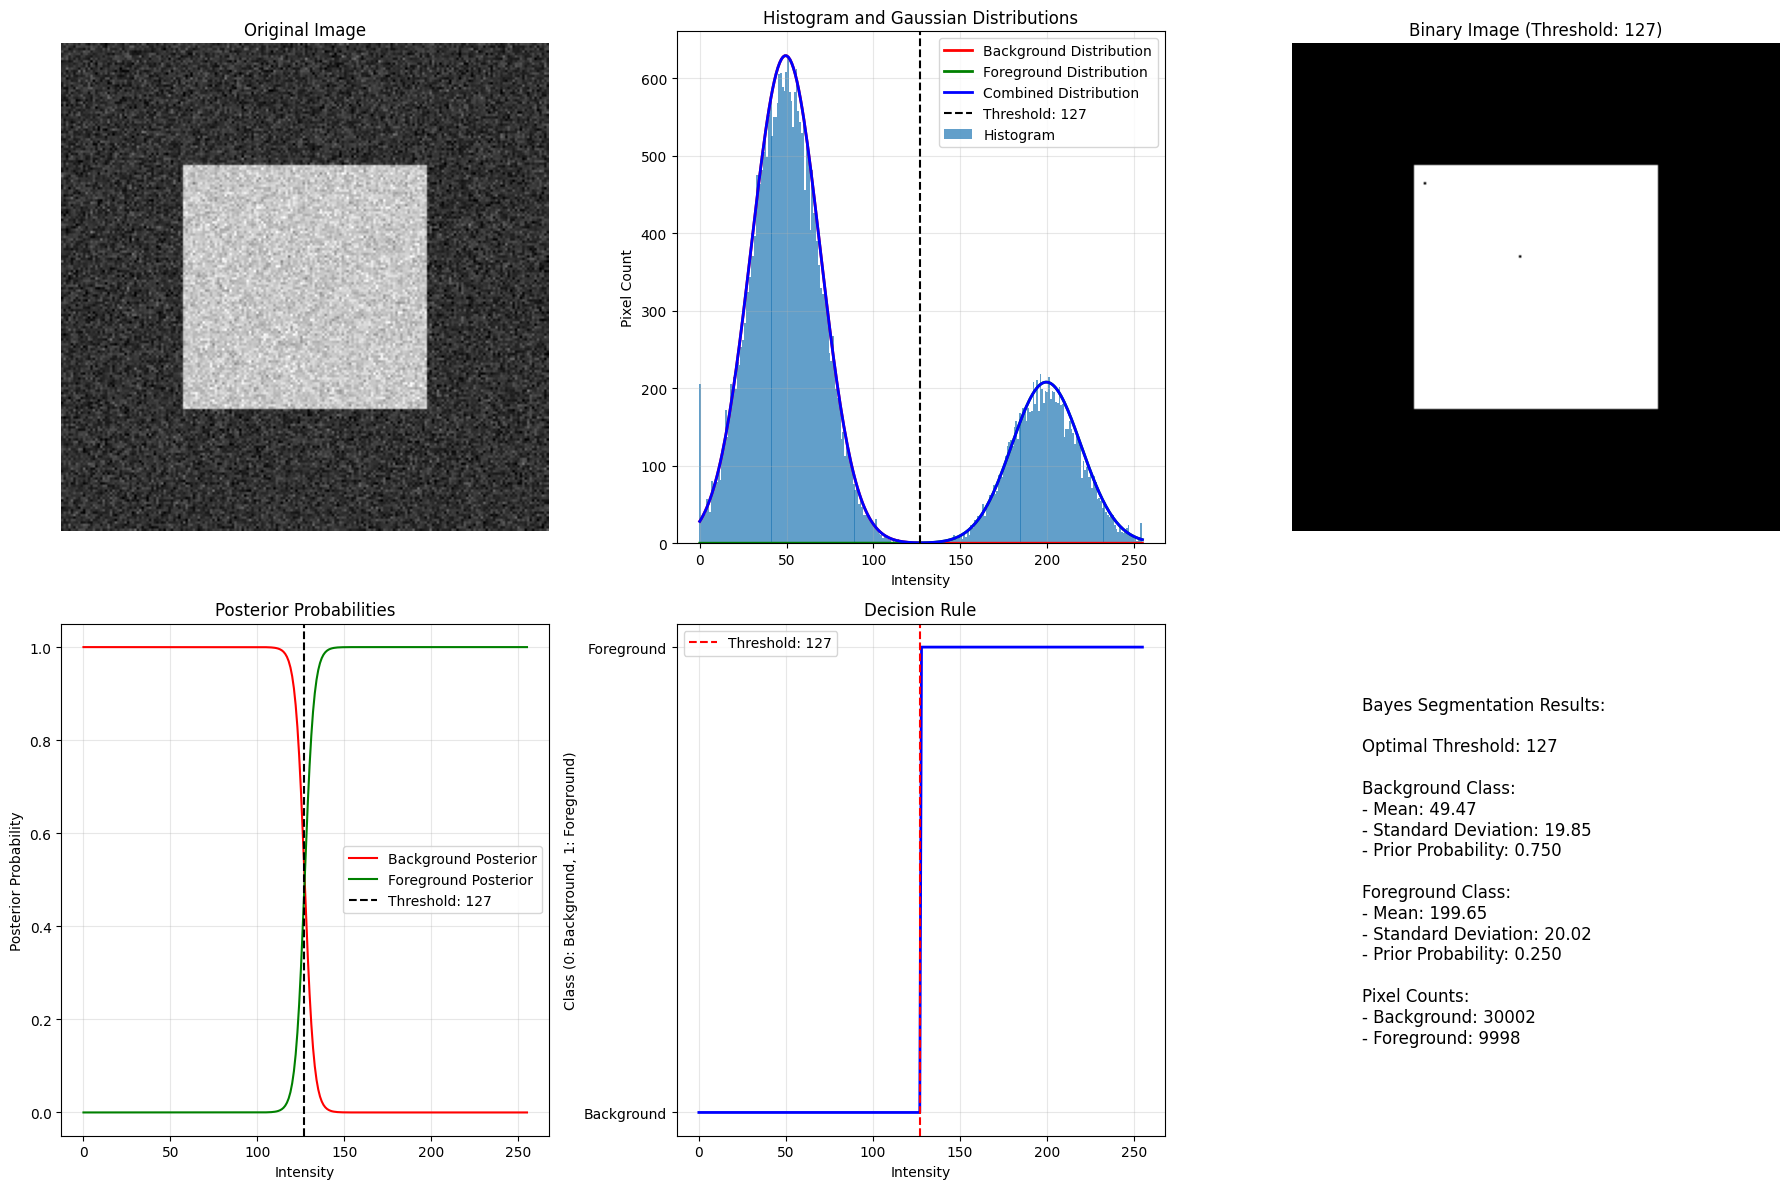


Test 2: Different intensity levels
Starting Bayes segmentation algorithm...
Iteration 1:
  Threshold: 103.00
  Background - Mean: 29.73, Std: 14.63, Prior: 0.510
  Foreground - Mean: 179.25, Std: 14.89, Prior: 0.490
Iteration 2:
  Threshold: 104.00
  Background - Mean: 29.73, Std: 14.63, Prior: 0.510
  Foreground - Mean: 179.25, Std: 14.89, Prior: 0.490
Algorithm converged at iteration 2
Final threshold: 104


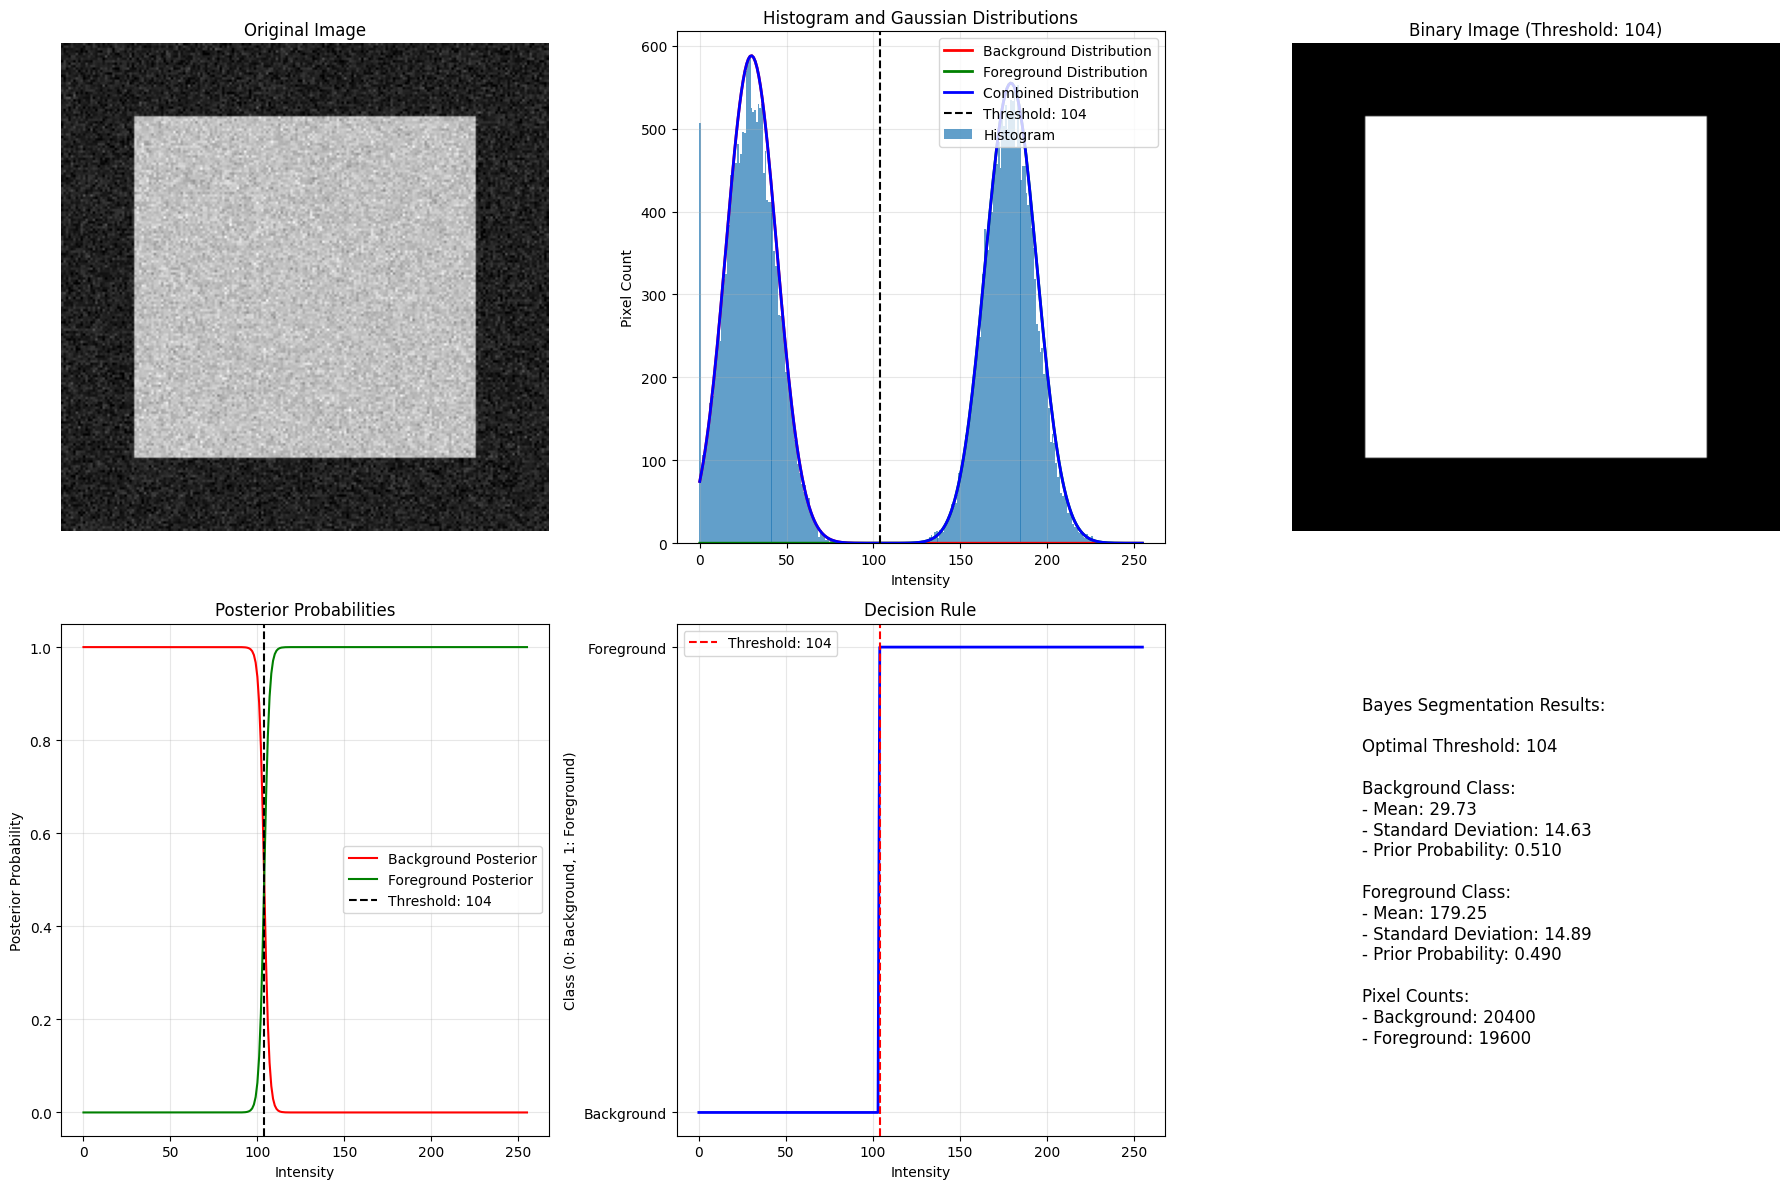


Test 3: High noise scenario
Starting Bayes segmentation algorithm...
Iteration 1:
  Threshold: 108.11
  Background - Mean: 65.92, Std: 28.41, Prior: 0.531
  Foreground - Mean: 155.89, Std: 33.87, Prior: 0.469
Iteration 2:
  Threshold: 110.00
  Background - Mean: 67.03, Std: 28.87, Prior: 0.545
  Foreground - Mean: 157.31, Std: 33.38, Prior: 0.455
Iteration 3:
  Threshold: 112.00
  Background - Mean: 68.08, Std: 29.32, Prior: 0.558
  Foreground - Mean: 158.68, Std: 32.91, Prior: 0.442
Iteration 4:
  Threshold: 114.00
  Background - Mean: 69.06, Std: 29.74, Prior: 0.570
  Foreground - Mean: 159.98, Std: 32.46, Prior: 0.430
Iteration 5:
  Threshold: 116.00
  Background - Mean: 70.04, Std: 30.18, Prior: 0.583
  Foreground - Mean: 161.29, Std: 32.01, Prior: 0.417
Iteration 6:
  Threshold: 118.00
  Background - Mean: 70.95, Std: 30.59, Prior: 0.594
  Foreground - Mean: 162.52, Std: 31.60, Prior: 0.406
Iteration 7:
  Threshold: 120.00
  Background - Mean: 72.00, Std: 31.07, Prior: 0.607
  Fo

c:\Programs\Anaconda3\envs\pth\lib\site-packages\scipy\stats\_distn_infrastructure.py:2046: RuntimeWarning: invalid value encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
c:\Programs\Anaconda3\envs\pth\lib\site-packages\scipy\stats\_distn_infrastructure.py:2046: RuntimeWarning: divide by zero encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)


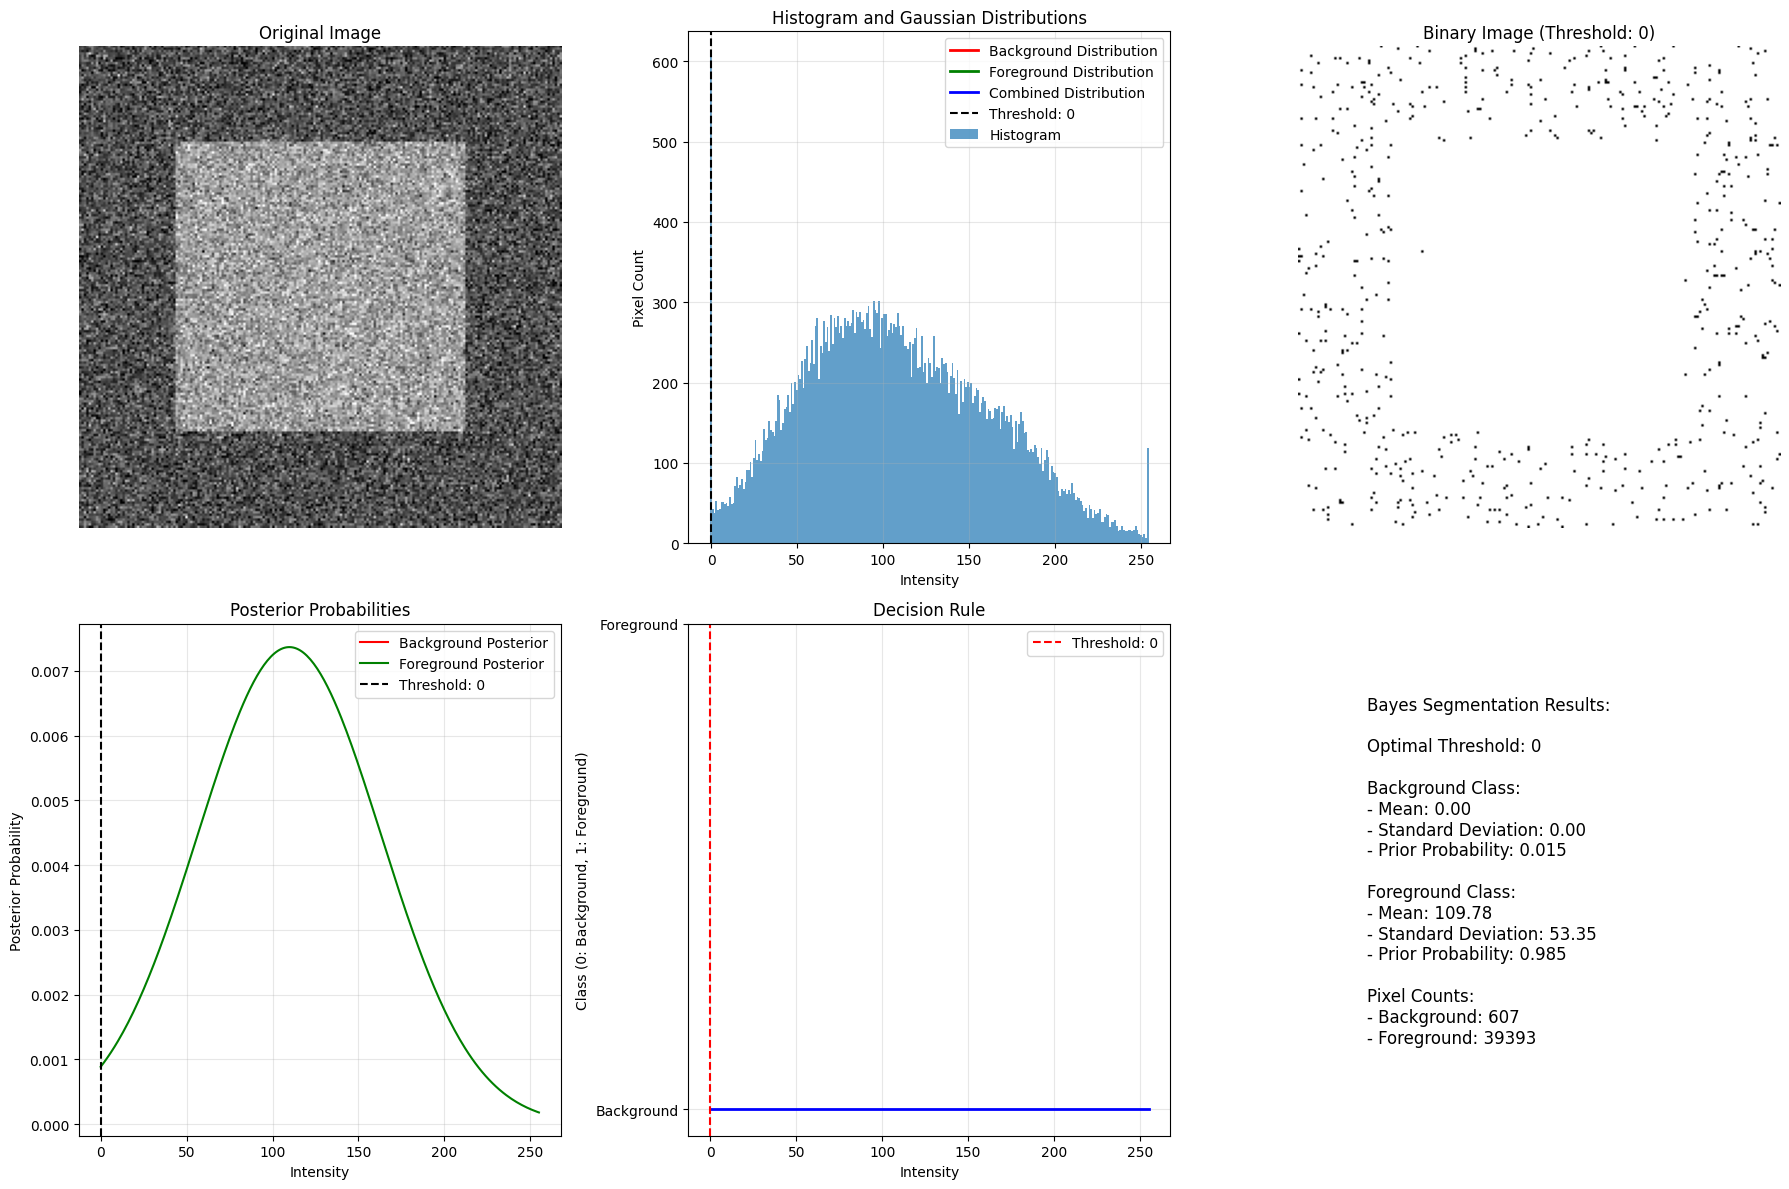


Final Results Summary:
Test 1: Optimal Threshold = 127
Test 2: Optimal Threshold = 104
Test 3: Optimal Threshold = 0


In [2]:
# --- Cell 1: Import Required Libraries ---
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.stats import norm
import cv2

# --- Cell 2: Function to Create Test Image ---
def create_test_image(size=(200, 200), rect_coords=(50, 50, 150, 150), 
                     bg_intensity=50, fg_intensity=200, noise_std=25):
    """
    Create a test image with a bright rectangle on dark background
    
    Parameters:
    -----------
    size : tuple
        Image dimensions (height, width)
    rect_coords : tuple
        Rectangle coordinates (y1, x1, y2, x2)
    bg_intensity : int
        Background intensity (0-255)
    fg_intensity : int
        Foreground (rectangle) intensity (0-255)
    noise_std : float
        Standard deviation of Gaussian noise
    
    Returns:
    --------
    image_array : ndarray
        Generated test image
    """
    # Create dark background
    image_array = np.full(size, bg_intensity, dtype=np.uint8)
    
    # Add bright rectangle
    y1, x1, y2, x2 = rect_coords
    image_array[y1:y2, x1:x2] = fg_intensity
    
    # Add Gaussian noise
    noise = np.random.normal(0, noise_std, size)
    image_array = np.clip(image_array.astype(np.float64) + noise, 0, 255).astype(np.uint8)
    
    return image_array

# --- Cell 3: Bayes Threshold Segmentation Function ---
def bayes_threshold_segmentation(image, max_iterations=100, tolerance=1e-6):
    """
    Image segmentation using Naive Bayes method
    
    Parameters:
    -----------
    image : ndarray
        Input image (grayscale)
    max_iterations : int
        Maximum number of EM algorithm iterations
    tolerance : float
        Convergence tolerance
    
    Returns:
    --------
    threshold : float
        Optimal threshold
    bg_params : tuple
        Background class parameters (mean, std, prior)
    fg_params : tuple
        Foreground class parameters (mean, std, prior)
    """
    
    # Convert image to 1D array
    pixels = image.flatten().astype(np.float64)
    
    # Initial threshold (image mean)
    threshold = np.mean(pixels)
    prev_threshold = 0
    
    print("Starting Bayes segmentation algorithm...")
    print("=" * 50)
    
    for iteration in range(max_iterations):
        # Check convergence
        if abs(threshold - prev_threshold) < tolerance:
            print(f"Algorithm converged at iteration {iteration}")
            break
        
        prev_threshold = threshold
        
        # Split pixels into two classes based on current threshold
        background_pixels = pixels[pixels <= threshold]
        foreground_pixels = pixels[pixels > threshold]
        
        # Calculate statistical parameters for each class
        # Background class
        bg_mean = np.mean(background_pixels) if len(background_pixels) > 0 else 0
        bg_std = np.std(background_pixels) if len(background_pixels) > 0 else 1
        
        # Foreground class
        fg_mean = np.mean(foreground_pixels) if len(foreground_pixels) > 0 else 255
        fg_std = np.std(foreground_pixels) if len(foreground_pixels) > 0 else 1
        
        # Calculate prior probabilities
        bg_prior = len(background_pixels) / len(pixels)
        fg_prior = len(foreground_pixels) / len(pixels)
        
        print(f"Iteration {iteration + 1}:")
        print(f"  Threshold: {threshold:.2f}")
        print(f"  Background - Mean: {bg_mean:.2f}, Std: {bg_std:.2f}, Prior: {bg_prior:.3f}")
        print(f"  Foreground - Mean: {fg_mean:.2f}, Std: {fg_std:.2f}, Prior: {fg_prior:.3f}")
        
        # Calculate posterior probabilities for all intensity levels
        posteriors_background = []
        posteriors_foreground = []
        
        for intensity in range(256):
            # Likelihood
            bg_likelihood = norm.pdf(intensity, bg_mean, bg_std)
            fg_likelihood = norm.pdf(intensity, fg_mean, fg_std)
            
            # Posterior
            bg_posterior = bg_prior * bg_likelihood
            fg_posterior = fg_prior * fg_likelihood
            
            # Normalization
            total_probability = bg_posterior + fg_posterior
            if total_probability > 0:
                bg_posterior /= total_probability
                fg_posterior /= total_probability
            
            posteriors_background.append(bg_posterior)
            posteriors_foreground.append(fg_posterior)
        
        # Find new threshold (point where posterior probabilities are equal)
        new_threshold = 0
        min_difference = float('inf')
        
        for intensity in range(256):
            difference = abs(posteriors_background[intensity] - posteriors_foreground[intensity])
            if difference < min_difference:
                min_difference = difference
                new_threshold = intensity
        
        threshold = new_threshold
    
    print("=" * 50)
    print(f"Final threshold: {threshold}")
    
    return threshold, (bg_mean, bg_std, bg_prior), (fg_mean, fg_std, fg_prior)

# --- Cell 4: Function to Apply Segmentation and Display Results ---
def apply_bayes_segmentation(image_path=None, image_array=None, use_test_image=False):
    """
    Apply Bayes segmentation to image and display results
    
    Parameters:
    -----------
    image_path : str
        Path to input image
    image_array : ndarray
        Input image as numpy array
    use_test_image : bool
        Whether to use generated test image
    """
    
    if image_path:
        # Load image from file
        image = Image.open(image_path).convert('L')
        image_array = np.array(image)
    elif image_array is not None:
        image = Image.fromarray(image_array)
    elif use_test_image:
        # Create test image
        image_array = create_test_image()
        image = Image.fromarray(image_array)
    else:
        raise ValueError("Either image_path, image_array, or use_test_image must be provided")
    
    # Apply Bayes method
    threshold, bg_params, fg_params = bayes_threshold_segmentation(image_array)
    
    # Create binary image
    binary_image = (image_array > threshold).astype(np.uint8) * 255
    
    # Calculate histogram
    histogram, bins = np.histogram(image_array.flatten(), bins=256, range=(0, 255))
    
    # Calculate Gaussian distributions
    x = np.linspace(0, 255, 256)
    bg_distribution = bg_params[2] * norm.pdf(x, bg_params[0], bg_params[1])
    fg_distribution = fg_params[2] * norm.pdf(x, fg_params[0], fg_params[1])
    total_distribution = bg_distribution + fg_distribution
    
    # Display results
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # Original image
    axes[0, 0].imshow(image_array, cmap='gray')
    axes[0, 0].set_title('Original Image')
    axes[0, 0].axis('off')
    
    # Histogram and distributions
    axes[0, 1].bar(bins[:-1], histogram, alpha=0.7, label='Histogram', width=1)
    axes[0, 1].plot(x, bg_distribution * max(histogram) / max(total_distribution), 
                   'r-', linewidth=2, label='Background Distribution')
    axes[0, 1].plot(x, fg_distribution * max(histogram) / max(total_distribution), 
                   'g-', linewidth=2, label='Foreground Distribution')
    axes[0, 1].plot(x, total_distribution * max(histogram) / max(total_distribution), 
                   'b-', linewidth=2, label='Combined Distribution')
    axes[0, 1].axvline(threshold, color='black', linestyle='--', 
                      label=f'Threshold: {threshold}')
    axes[0, 1].set_xlabel('Intensity')
    axes[0, 1].set_ylabel('Pixel Count')
    axes[0, 1].set_title('Histogram and Gaussian Distributions')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Binary image
    axes[0, 2].imshow(binary_image, cmap='gray')
    axes[0, 2].set_title(f'Binary Image (Threshold: {threshold})')
    axes[0, 2].axis('off')
    
    # Posterior probabilities
    pixels = image_array.flatten()
    posteriors_bg = []
    posteriors_fg = []
    
    for intensity in range(256):
        bg_likelihood = norm.pdf(intensity, bg_params[0], bg_params[1])
        fg_likelihood = norm.pdf(intensity, fg_params[0], fg_params[1])
        
        bg_posterior = bg_params[2] * bg_likelihood
        fg_posterior = fg_params[2] * fg_likelihood
        
        total = bg_posterior + fg_posterior
        if total > 0:
            bg_posterior /= total
            fg_posterior /= total
        
        posteriors_bg.append(bg_posterior)
        posteriors_fg.append(fg_posterior)
    
    axes[1, 0].plot(range(256), posteriors_bg, 'r-', label='Background Posterior')
    axes[1, 0].plot(range(256), posteriors_fg, 'g-', label='Foreground Posterior')
    axes[1, 0].axvline(threshold, color='black', linestyle='--', 
                      label=f'Threshold: {threshold}')
    axes[1, 0].set_xlabel('Intensity')
    axes[1, 0].set_ylabel('Posterior Probability')
    axes[1, 0].set_title('Posterior Probabilities')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Decision rule visualization
    decision_boundary = np.argmax(np.array([posteriors_bg, posteriors_fg]), axis=0)
    axes[1, 1].plot(range(256), decision_boundary, 'b-', linewidth=2)
    axes[1, 1].axvline(threshold, color='red', linestyle='--', 
                      label=f'Threshold: {threshold}')
    axes[1, 1].set_xlabel('Intensity')
    axes[1, 1].set_ylabel('Class (0: Background, 1: Foreground)')
    axes[1, 1].set_title('Decision Rule')
    axes[1, 1].set_yticks([0, 1])
    axes[1, 1].set_yticklabels(['Background', 'Foreground'])
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    # Statistical information
    axes[1, 2].axis('off')
    info_text = f"""
    Bayes Segmentation Results:
    
    Optimal Threshold: {threshold}
    
    Background Class:
    - Mean: {bg_params[0]:.2f}
    - Standard Deviation: {bg_params[1]:.2f}
    - Prior Probability: {bg_params[2]:.3f}
    
    Foreground Class:
    - Mean: {fg_params[0]:.2f}
    - Standard Deviation: {fg_params[1]:.2f}
    - Prior Probability: {fg_params[2]:.3f}
    
    Pixel Counts:
    - Background: {int(bg_params[2] * len(pixels))}
    - Foreground: {int(fg_params[2] * len(pixels))}
    """
    axes[1, 2].text(0.1, 0.9, info_text, transform=axes[1, 2].transAxes, 
                   fontsize=12, verticalalignment='top')
    
    plt.tight_layout()
    plt.show()
    
    return threshold, binary_image, bg_params, fg_params

# --- Cell 5: Test the Algorithm ---
def test_bayes_segmentation():
    """Test the Bayes segmentation algorithm with different scenarios"""
    
    print("Testing Bayes Image Segmentation Method")
    print("=" * 50)
    
    # Test 1: Simple test image
    print("\nTest 1: Simple test image")
    test_image1 = create_test_image(size=(200, 200), 
                                  rect_coords=(50, 50, 150, 150),
                                  bg_intensity=50, fg_intensity=200,
                                  noise_std=20)
    threshold1, binary1, bg_params1, fg_params1 = apply_bayes_segmentation(image_array=test_image1)
    
    # Test 2: Different intensity levels
    print("\nTest 2: Different intensity levels")
    test_image2 = create_test_image(size=(200, 200),
                                  rect_coords=(30, 30, 170, 170),
                                  bg_intensity=30, fg_intensity=180,
                                  noise_std=15)
    threshold2, binary2, bg_params2, fg_params2 = apply_bayes_segmentation(image_array=test_image2)
    
    # Test 3: High noise scenario
    print("\nTest 3: High noise scenario")
    test_image3 = create_test_image(size=(200, 200),
                                  rect_coords=(40, 40, 160, 160),
                                  bg_intensity=80, fg_intensity=160,
                                  noise_std=40)
    threshold3, binary3, bg_params3, fg_params3 = apply_bayes_segmentation(image_array=test_image3)
    
    return (threshold1, threshold2, threshold3)

# --- Cell 6: Main Execution ---
if __name__ == "__main__":
    # Run comprehensive tests
    thresholds = test_bayes_segmentation()
    
    print("\nFinal Results Summary:")
    print("=" * 30)
    for i, threshold in enumerate(thresholds, 1):
        print(f"Test {i}: Optimal Threshold = {threshold}")

## Summary and Key Points

### Advantages of Bayes Method:
1. **Probability-based**: Strong theoretical foundation
2. **Flexible**: Can be extended to multiple classes
3. **Uncertainty quantification**: Posterior probabilities show confidence levels

### Limitations:
1. **Gaussian distribution assumption**: May not hold for all images
2. **Sensitivity to initialization**: May converge to local optima in some cases
3. **Computational complexity**: More complex than simpler methods

### Applications:
- Medical image segmentation
- Text extraction from images
- Microscopy image analysis
- Satellite image processing

This method forms the basis for understanding more advanced methods like GMM (Gaussian Mixture Models) and other probability-based approaches.

## Mathematical Formulation

### Expectation-Maximization (EM) Algorithm

The Bayes segmentation uses an EM-like approach:

1. **E-step**: Calculate posterior probabilities
   $$
   P(C_k | x_i) = \frac{P(x_i | C_k) P(C_k)}{\sum_{j} P(x_i | C_j) P(C_j)}
   $$

2. **M-step**: Update parameters
   $$
   \mu_k = \frac{\sum_i P(C_k | x_i) x_i}{\sum_i P(C_k | x_i)}
   $$
   $$
   \sigma_k^2 = \frac{\sum_i P(C_k | x_i) (x_i - \mu_k)^2}{\sum_i P(C_k | x_i)}
   $$
   $$
   P(C_k) = \frac{\sum_i P(C_k | x_i)}{N}
   $$

This iterative process continues until convergence, providing the optimal segmentation threshold.